# Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import sklearn as sk
import numpy as np
from utils.BayesClassifier import Binary, BinaryMVG, BinaryNaiveBayes, BinaryTiedVariance
from utils.utils import evaluate_model, vcol, load_data, split_db_2to1
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
np.set_printoptions(linewidth=100, precision=2)

# Lab

## Confusion matrices

In [4]:
evalset_ll = np.load('../data/evalset_ll.npy')
evalset_labels = np.load('../data/evalset_labels.npy')
classes = np.unique(evalset_labels).tolist()

In [5]:
pred = np.argmax(evalset_ll, axis=0)
err, cm = evaluate_model(evalset_labels, pred, classes)

In [6]:
print(cm)

[[210. 113.  61.]
 [137. 191. 111.]
 [ 53.  98. 230.]]


## Optimal Bayes decisions

In [7]:
llr = np.load('../data/evalset_llr_binary.npy')
y = np.load('../data/evalset_labels_binary.npy')

In [8]:
model = Binary()
model.labels = np.unique(y).tolist()
model.llr = llr

In [9]:
pi1 = 0.8
Cfn = 1
Cfp = 10

costs = np.array([
    [0, Cfn],
    [Cfp, 0]
])

priors = vcol(np.array([(1-pi1), pi1]))

model.set_cost_matrix(costs)
model.set_priors(priors)


In [10]:
model.set_optimal_thresold()
model.pred = np.where(model.llr >= model.t, 1, 0)
err, cm, DCFu, DCF = model.evaluate(y)
print(cm)
print(f"{DCFu:.4f}")
print(f"{DCF:.4f}")


[[302. 113.]
 [100. 287.]]
0.7235
0.9044


## Minimum detection costs

In [11]:
print(model.calc_minDCF(y))

0.70931592039801


## Bayes error plots

In [12]:
effPriorLogOdds = np.linspace(-3, 3, 21)
effPi = 1/(1+np.exp(-effPriorLogOdds))

In [13]:
costs = np.array([
    [0, 1],
    [1, 0]
])
model.set_cost_matrix(costs)


DCFs = []
minDCFs = []

for pi in effPi:
    model.set_priors(vcol(np.array([(1-pi), pi])))

    model.set_optimal_thresold()
    model.pred = np.where(model.llr >= model.t, 1, 0)
    err, cm, DCFu, DCF = model.evaluate(y)
    DCFs.append(DCF)

    minDCFs.append(model.calc_minDCF(y))

DCFs = np.array(DCFs)
minDCFs = np.array(minDCFs)

(-3.0, 3.0)

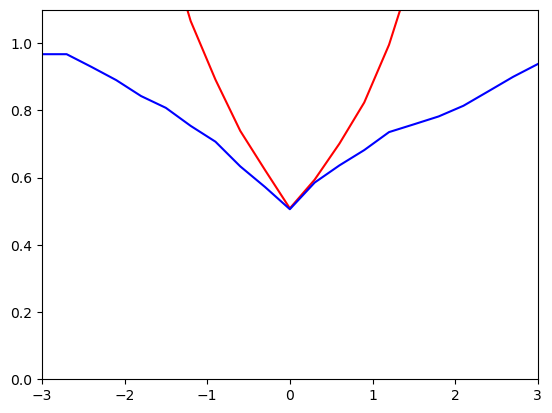

In [14]:
plt.plot(effPriorLogOdds, DCFs, label="DCF", color="r")
plt.plot(effPriorLogOdds, minDCFs, label="min DCF", color="b")
plt.ylim([0, 1.1])
plt.xlim([-3, 3])

# Project

## Data

In [15]:
PROJECT_FILE = "../data/trainData.txt"
D, L, labels = load_data(PROJECT_FILE)
feature_names = [f'F{i}' for i in range(0, D.shape[0])]
L = L.astype(int)
labels = [0, 1]
(DTR, LTR), (DTE, LTE) = split_db_2to1(D, L)

## Eval

In [16]:
m = BinaryMVG()
m.fit(DTR, LTR)

In [17]:
def calc_eff_prior(p, Cfn, Cfp): 
    return (p*Cfn) / (p*Cfn + (1-p)*Cfp)

In [18]:
costs = np.array([
    [0, 1],
    [1, 0]
])

m.set_cost_matrix(costs)

In [ ]:
effP = [
    calc_eff_prior(0.5, 1, 1),
    calc_eff_prior(0.9, 1, 1),
    calc_eff_prior(0.1, 1, 1),
    calc_eff_prior(0.5, 1, 9),
    calc_eff_prior(0.5, 9, 1)
]
print(effP)

[0.5, 0.9, 0.1, 0.1, 0.9]


In [20]:
for p in effP:
    m.set_priors(vcol(np.array([(1-p), p])))
    m.set_optimal_thresold()
    m.predict(DTE)
    err, cm, DCFu, DCF = m.evaluate(LTE)
    print("Effective Prior: ", p)
    print(cm)
    print("DCF: ", DCF)
    print("\n")

Effective Prior:  0.5
[[927.  75.]
 [ 65. 933.]]
DCF:  0.13992895545314898


Effective Prior:  0.9
[[728.  15.]
 [264. 993.]]
DCF:  0.40005760368663595


Effective Prior:  0.1
[[988. 271.]
 [  4. 737.]]
DCF:  0.3051395289298515


Effective Prior:  0.1
[[988. 271.]
 [  4. 737.]]
DCF:  0.3051395289298515


Effective Prior:  0.9
[[728.  15.]
 [264. 993.]]
DCF:  0.40005760368663595




## Models

In [21]:
mvg = BinaryMVG()
nb = BinaryNaiveBayes()
tv = BinaryTiedVariance()

mvg.fit(DTR, LTR)
nb.fit(DTR, LTR)
tv.fit(DTR, LTR)

costs = np.array([
    [0, 1],
    [1, 0]
])

mvg.set_cost_matrix(costs)
nb.set_cost_matrix(costs)
tv.set_cost_matrix(costs)

- **DCF**

| model \ Effective Prior | 0.1 | 0.5 | 0.9 |
| ----- | ---- | ----| ---- |
| MVG | 0.305 | 0.140 | 0.400 |
| NB | 0.302 | 0.144 | 0.389 |
| TV | 0.406 | 0.186 | 0.463 |

- **MinDCF**

| model \ Effective Prior | 0.1 | 0.5 | 0.9 |
| ----- | ---- | ----| ---- |
| MVG | 0.263 | 0.130 | 0.342 |
| NB | 0.257 | 0.131 | 0.351 |
| TV | 0.363 | 0.181 | 0.442 |

In [22]:
ep = 0.9

tv.set_priors(vcol(np.array([(1-ep), ep])))
tv.set_optimal_thresold()
tv.predict(DTE)
err, cm, DCFu, DCF = tv.evaluate(LTE)
minDCF = tv.calc_minDCF(LTE)
print(f"DCF: {DCF: .3f}")
print(f"minDCF: {minDCF: .3f}")

DCF:  0.463
minDCF:  0.442



## Plots

In [23]:
effPriorLogOdds = np.linspace(-4, 4, 21)
effPi = 1/(1+np.exp(-effPriorLogOdds))

In [24]:
costs = np.array([
    [0, 1],
    [1, 0]
])
model.set_cost_matrix(costs)


DCFs_mvg = []
minDCFs_mvg = []

DCFs_nb = []
minDCFs_nb = []

DCFs_tv = []
minDCFs_tv = []

for pi in effPi:
    mvg.set_priors(vcol(np.array([(1-pi), pi])))
    mvg.set_optimal_thresold()
    mvg.predict(DTE)
    err, cm, DCFu, DCF = mvg.evaluate(LTE)
    DCFs_mvg.append(DCF)
    minDCFs_mvg.append(mvg.calc_minDCF(LTE))

    nb.set_priors(vcol(np.array([(1-pi), pi])))
    nb.set_optimal_thresold()
    nb.predict(DTE)
    err, cm, DCFu, DCF = nb.evaluate(LTE)
    DCFs_nb.append(DCF)
    minDCFs_nb.append(nb.calc_minDCF(LTE))

    tv.set_priors(vcol(np.array([(1-pi), pi])))
    tv.set_optimal_thresold()
    tv.predict(DTE)
    err, cm, DCFu, DCF = tv.evaluate(LTE)
    DCFs_tv.append(DCF)
    minDCFs_tv.append(tv.calc_minDCF(LTE))


DCFs_mvg = np.array(DCFs_mvg)
minDCFs_mvg = np.array(minDCFs_mvg)

DCFs_nb = np.array(DCFs_nb)
minDCFs_nb = np.array(minDCFs_nb)

DCFs_tv = np.array(DCFs_tv)
minDCFs_tv = np.array(minDCFs_tv)

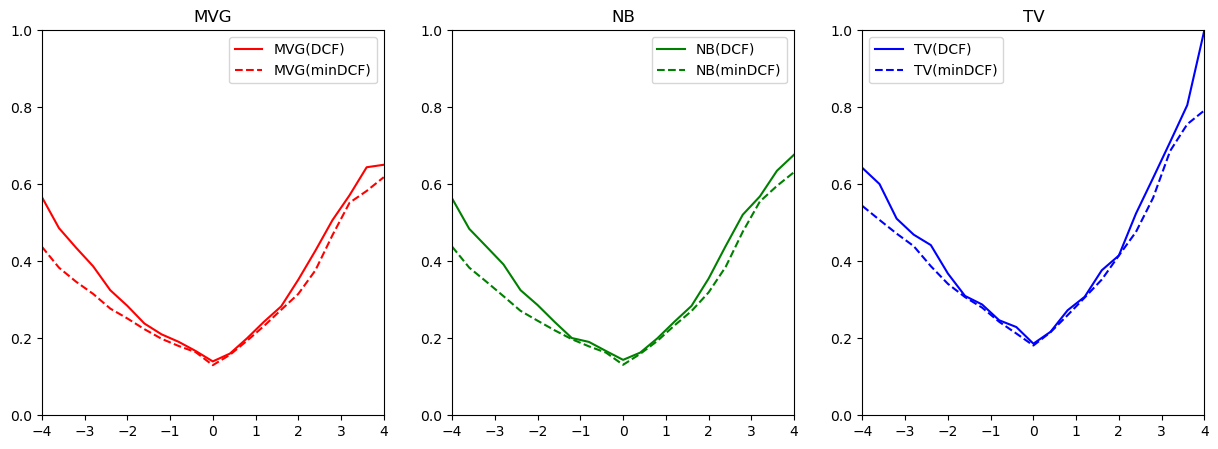

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].set_title("MVG")
ax[1].set_title("NB")
ax[2].set_title("TV")

ax[0].plot(effPriorLogOdds, DCFs_mvg, label="MVG(DCF)", color="r")
ax[0].plot(effPriorLogOdds, minDCFs_mvg, label="MVG(minDCF)", color="r", ls="--")
ax[1].plot(effPriorLogOdds, DCFs_nb, label="NB(DCF)", color="g")
ax[1].plot(effPriorLogOdds, minDCFs_nb, label="NB(minDCF)", color="g", ls="--")
ax[2].plot(effPriorLogOdds, DCFs_tv, label="TV(DCF)", color="b")
ax[2].plot(effPriorLogOdds, minDCFs_tv, label="TV(minDCF)", color="b", ls="--")
ax[0].set_ylim([0, 1])
ax[0].set_xlim([-4, 4])
ax[1].set_ylim([0, 1])
ax[1].set_xlim([-4, 4])
ax[2].set_ylim([0, 1])
ax[2].set_xlim([-4, 4])
ax[0].legend()
ax[1].legend()
ax[2].legend()
